## Access this Notebook
You can launch this notebook in the US GHG Center JupyterHub by clicking the link below. If you are a new user, you should first sign up for the hub by filling out this [**request form**](https://docs.google.com/forms/d/e/1FAIpQLSdai8otCdrVQzJgev8mjDhzKyCg7jcrB3UeTXNHoCiaMKrkaQ/viewform) and providing the required information. 


Access the [**GEDI Aboveground Biomass Density**](https://us-ghg-center.github.io/ghgc-docs/user_data_notebooks/gedi-iss-l4B-aboveground-biomass-density-mean_User_Notebook.html) notebook in the US GHG Center JupyterHub.

## Table of Contents
- [Data Summary and Application](#data-summary-and-application)
- [Approach](#approach)
- [About the Data](#about-the-data)
- [Install the Required Libraries](#install-the-required-libraries)
- [Terminology](#terminology)
- [Query the STAC API](#query-the-stac-api)
- [Helper Functions](#helper-functions-for-spatial-data-processing)
- [Visualizing Biomass Density](#visualizing-biomass-density)
- [Comparing Biomass Across Regions](#comparing-biomass-across-regions)
- [Interactive Spatial Comparison](#interactive-spatial-comparison)
- [Summary](#summary)

## Data Summary and Application
- **Spatial coverage**: Global (51.6°N to 51.6°S) and (-180.0°W to 180.0°E)
- **Spatial resolution**: 1 km × 1 km
- **Temporal extent**: April 2019 - March 2023
- **Unit**: Megagrams of biomass per hectare (Mg/ha)
- **Utility**: Forest Carbon Monitoring and Climate Research

For more information, visit the [GEDI Aboveground Biomass Density](https://daac.ornl.gov/GEDI/guides/GEDI_L4B_Gridded_Biomass_V2_1.html) data overview page.

## Approach

This notebook demonstrates how to visualize and compare GEDI aboveground biomass density data across different forest regions using STAC metadata and pre-rendered WMTS imagery:

1. **Connect to STAC API** - Access the GEDI biomass collection metadata from the US GHG Center.
2. **Define Tile Matrix** - Use the 1km tile matrix in EPSG:4326 projection for global coverage.
3. **Fetch GEDI Imagery** - Retrieve pre-rendered biomass density tiles from NASA GIBS WMTS service.
4. **Visualize Biomass Patterns** - Display biomass density using the gist_earth colormap with values up to 250 Mg/ha.
5. **Compare Forest Regions** - Analyze side-by-side biomass differences between major forest ecosystems worldwide.
6. **Interactive Region Selection** - Use dropdown widgets to select and compare high-biomass forest regions.
7. **Add Visual Enhancements** - Include coordinate grids, labels, and location markers for spatial context.
8. **Interpret Results** - Understand biomass distribution patterns and their importance for carbon monitoring.

## About the Data
### GEDI Aboveground Biomass Density
The Global Ecosystem Dynamics Investigation (GEDI) mission provides high-resolution laser ranging observations of Earth's 3D structure from the International Space Station (ISS). GEDI's L4B product delivers 1 km × 1 km mean aboveground biomass density (AGBD) estimates derived from GEDI's lidar waveform measurements. These estimates are crucial for understanding global carbon stocks, monitoring deforestation, and assessing climate change mitigation potential through forest conservation and restoration. The data covers global tropical and temperate forests between 51.6°N and 51.6°S latitude, providing unprecedented detail on forest structure and biomass distribution.

For more information regarding this dataset, please visit the [U.S. Greenhouse Gas Center](https://earth.gov/ghgcenter).

## Terminology
Navigating data via the GHGC API, you will encounter terminology that is different from browsing in a typical filesystem. We'll define some terms here which are used throughout this notebook.
- `catalog`:    All datasets available at the `/stac` endpoint
- `collection`: A specific dataset, e.g. GEDI Aboveground Biomass Density
- `item`:       One granule in the dataset, e.g. one annual mean file
- `asset`:      A variable available within the granule, e.g. biomass density
- `STAC API`:   **Sp**atio**T**emporal **A**sset **C**atalogs - Endpoint for fetching metadata about available datasets

## Install the Required Libraries
Required libraries are pre-installed on the GHG Center Hub. If you need to run this notebook elsewhere, please install them with this line in a code cell:

`%pip install requests pystac_client matplotlib numpy ipywidgets pillow --quiet`

In [174]:
# Import required libraries
import requests
from datetime import datetime
from typing import List, Tuple, Dict
from io import BytesIO
import numpy as np

# For data visualization
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from matplotlib.gridspec import GridSpec

# For image processing
from PIL import Image

# For accessing the STAC API
from pystac_client import Client

## Query the STAC API
### STAC API Collection Names

Now, you must fetch the dataset from the [**STAC API**](https://earth.gov/ghgcenter/api/stac/) by defining its associated STAC API collection ID as a variable. 
The collection ID, also known as the **collection name**, for the GEDI Aboveground Biomass Density dataset is [**GEDI_ISS_L4B_Aboveground_Biomass_Density_Mean_201904-202303**](https://earth.gov/ghgcenter/api/stac/collections/GEDI_ISS_L4B_Aboveground_Biomass_Density_Mean_201904-202303).

**You can find the collection name of any dataset on the GHGC data portal by navigating to the dataset landing page within the data catalog. The collection name is the last portion of the dataset landing page's URL, and is also listed in the pop-up box after clicking "ACCESS DATA."*

In [175]:
# Provide the STAC and RASTER API endpoints
# The endpoint is referring to a location within the API that executes a request on a data collection nesting on the server.

# The STAC API is a catalog of all the existing data collections that are stored in the GHG Center.
STAC_API_URL = "https://dev.ghg.center/api/stac"

# The collection name is used to fetch metadata from the STAC API.
COLLECTION_NAME = "GEDI_ISS_L4B_Aboveground_Biomass_Density_Mean_201904-202303"

# NASA GIBS WMTS endpoint for GEDI data
GIBS_WMTS_URL = "https://gibs.earthdata.nasa.gov/wmts/epsg4326/best/wmts.cgi"
GEDI_LAYER = "GEDI_ISS_L4B_Aboveground_Biomass_Density_Mean_201904-202303"

# GEDI data date (this is a composite dataset, so any date within the range works). But this date is all that is needed for all tiles.
GEDI_DATE = "2019-04-18"

# Load collection
catalog = Client.open(STAC_API_URL)
collection = catalog.get_collection(COLLECTION_NAME)
display(collection)

<CollectionClient id=GEDI_ISS_L4B_Aboveground_Biomass_Density_Mean_201904-202303>

## Tile Info 

Each image is broken down into a differing number of tiles when requests for a specific location are provided as inputs. To improve the understanding of which tiles are being plotted when a specific location is requested, provided below are the dimensions for the entire image when a specific zoom level is requested. Each zoom level has a specific number of tiles which correspond to different regions of the world based on latitude and longitude.

For GEDI data, we use the 1km tile matrix set in EPSG:4326 projection which provides global coverage at multiple zoom levels.

In [176]:
# GEDI uses 1km tile matrix for EPSG:4326
GEDI_TILE_MATRIX = {
    0: {'width': 2, 'height': 1, 'tile_width': 180.0, 'tile_height': 180.0},
    1: {'width': 3, 'height': 2, 'tile_width': 120.0, 'tile_height': 90.0},
    2: {'width': 5, 'height': 3, 'tile_width': 72.0, 'tile_height': 60.0},
    3: {'width': 10, 'height': 5, 'tile_width': 36.0, 'tile_height': 36.0},
    4: {'width': 20, 'height': 10, 'tile_width': 18.0, 'tile_height': 18.0},
    5: {'width': 40, 'height': 20, 'tile_width': 9.0, 'tile_height': 9.0}
}

print("GEDI 1km Tile Matrix Dimensions (EPSG:4326):")
print("Zoom | Grid Size  | Tile Coverage   | Total Tiles")
print("-----|------------|-----------------|------------")
for zoom, params in GEDI_TILE_MATRIX.items():
    total_tiles = params['width'] * params['height']
    print(f"  {zoom}  | {params['width']:3d}×{params['height']:3d}    | {params['tile_width']:.1f}°×{params['tile_height']:.1f}°  | {total_tiles:,}")

GEDI 1km Tile Matrix Dimensions (EPSG:4326):
Zoom | Grid Size  | Tile Coverage   | Total Tiles
-----|------------|-----------------|------------
  0  |   2×  1    | 180.0°×180.0°  | 2
  1  |   3×  2    | 120.0°×90.0°  | 6
  2  |   5×  3    | 72.0°×60.0°  | 15
  3  |  10×  5    | 36.0°×36.0°  | 50
  4  |  20× 10    | 18.0°×18.0°  | 200
  5  |  40× 20    | 9.0°×9.0°  | 800


## Helper Functions for Spatial Data Processing
1. Convert longitude and latitude to GEDI tile indices (function `lonlat_to_gedi_tile`)
2. Get the bounding box of each tile (function `tile_to_bbox`)
3. Fetch the tile via an API request (function `fetch_gedi_tile`)
4. Plot the biomass density data with coordinate grid (function `display_biomass_tile`)
   - Includes customizable grid opacity parameter (0-1, default: 0.3)
   - Displays 5+ latitude/longitude labels with tick marks
   - Overlays white/black grid lines for better visibility
5. Add GEDI colorbar to visualizations (function `add_gedi_colorbar`)

The colorbar uses matplotlib's `gist_earth` colormap and represents aboveground biomass density values in Megagrams per hectare (Mg ha⁻¹) with a maximum value of 250:
- **0-50 Mg/ha**: Very low biomass (dark brown/purple)
- **50-100 Mg/ha**: Low biomass (brown to tan)
- **100-150 Mg/ha**: Moderate biomass (tan to light green)
- **150-200 Mg/ha**: High biomass (green)
- **200-250 Mg/ha**: Very high biomass (dark green)
- **≥250 Mg/ha**: Exceptional biomass (darkest green)

In [177]:
def lonlat_to_gedi_tile(lon: float, lat: float, zoom: int) -> Tuple[int, int]:
    """
    Convert longitude/latitude to GEDI tile coordinates.
    """
    if zoom not in GEDI_TILE_MATRIX:
        raise ValueError(f"Zoom level {zoom} not supported")
    
    matrix = GEDI_TILE_MATRIX[zoom]
    col = int((lon + 180) / matrix['tile_width'])
    row = int((90 - lat) / matrix['tile_height'])
    
    # Clamp to valid range
    col = max(0, min(col, matrix['width'] - 1))
    row = max(0, min(row, matrix['height'] - 1))
    
    return col, row

def tile_to_bbox(col: int, row: int, zoom: int) -> Tuple[float, float, float, float]:
    """
    Get the geographic bounding box for a GEDI tile.
    """
    matrix = GEDI_TILE_MATRIX[zoom]
    
    min_lon = -180 + (col * matrix['tile_width'])
    max_lon = min_lon + matrix['tile_width']
    max_lat = 90 - (row * matrix['tile_height'])
    min_lat = max_lat - matrix['tile_height']
    
    return min_lon, max_lon, min_lat, max_lat

def fetch_gedi_tile(col: int, row: int, zoom: int, date: str = GEDI_DATE) -> Image:
    """
    Fetch a single GEDI biomass tile from NASA GIBS.
    """
    params = {
        'SERVICE': 'WMTS',
        'REQUEST': 'GetTile',
        'VERSION': '1.0.0',
        'LAYER': GEDI_LAYER,
        'STYLE': 'default',
        'TILEMATRIXSET': '1km',
        'TILEMATRIX': str(zoom),
        'TILEROW': str(row),
        'TILECOL': str(col),
        'FORMAT': 'image/png',
        'TIME': date
    }
    
    response = requests.get(GIBS_WMTS_URL, params=params)
    
    if response.status_code == 200:
        try:
            return Image.open(BytesIO(response.content))
        except Exception as e:
            print(f"❌ Error: Failed to parse image data for tile ({col},{row}) at zoom {zoom}")
            return None
    else:
        print(f"❌ Error: Failed to fetch tile ({col},{row}) at zoom {zoom} - Status {response.status_code}")
        return None

def format_coordinate(value, is_longitude=True):
    """
    Format a coordinate value with appropriate direction indicator.
    """
    if is_longitude:
        direction = "E" if value >= 0 else "W"
        abs_value = abs(value)
    else:
        direction = "N" if value >= 0 else "S"
        abs_value = abs(value)
    
    return f"{abs_value:.1f}°{direction}"

def display_biomass_tile(ax, img, date_str, location_name, bbox=None, zoom_level=None, grid_opacity=0.3):
    """
    Helper function to display a biomass tile image with coordinate labels, tick marks, and grid lines.
    """
    if img is not None:
        im = ax.imshow(img)
        
        # Add coordinate labels, ticks, and grid for zoom levels 2 and above
        if bbox is not None and zoom_level is not None and zoom_level >= 2:
            min_lon, max_lon, min_lat, max_lat = bbox
            img_width, img_height = img.size
            
            # Calculate number of labels based on tile size
            lon_range = max_lon - min_lon
            lat_range = max_lat - min_lat
            
            # Determine appropriate number of labels (at least 5)
            if lon_range <= 10:
                n_lon_labels = 5
            elif lon_range <= 20:
                n_lon_labels = 5
            else:
                n_lon_labels = 6
                
            if lat_range <= 10:
                n_lat_labels = 5
            elif lat_range <= 20:
                n_lat_labels = 5
            else:
                n_lat_labels = 6
            
            # Create longitude labels and positions
            lon_values = np.linspace(min_lon, max_lon, n_lon_labels)
            lon_positions = np.linspace(0, img_width, n_lon_labels)
            
            # Create latitude labels and positions
            lat_values = np.linspace(max_lat, min_lat, n_lat_labels)  # Note: reversed for image coordinates
            lat_positions = np.linspace(0, img_height, n_lat_labels)
            
            # Add vertical grid lines at longitude positions
            for lon_val, x_pos in zip(lon_values, lon_positions):
                # Draw vertical grid line
                ax.axvline(x=x_pos, color='white', linewidth=0.5, alpha=grid_opacity, linestyle='-')
                ax.axvline(x=x_pos, color='black', linewidth=0.3, alpha=grid_opacity*0.5, linestyle='-')
                
                # Add tick mark
                ax.plot([x_pos, x_pos], [img_height, img_height + 10], 'k-', clip_on=False, linewidth=1)
                # Add label
                label = format_coordinate(lon_val, is_longitude=True)
                ax.text(x_pos, img_height + 15, label, ha='center', va='top', 
                       fontsize=8, rotation=0, clip_on=False)
            
            # Add horizontal grid lines at latitude positions
            for lat_val, y_pos in zip(lat_values, lat_positions):
                # Draw horizontal grid line
                ax.axhline(y=y_pos, color='white', linewidth=0.5, alpha=grid_opacity, linestyle='-')
                ax.axhline(y=y_pos, color='black', linewidth=0.3, alpha=grid_opacity*0.5, linestyle='-')
                
                # Add tick mark
                ax.plot([img_width, img_width + 10], [y_pos, y_pos], 'k-', clip_on=False, linewidth=1)
                # Add label
                label = format_coordinate(lat_val, is_longitude=False)
                ax.text(img_width + 15, y_pos, label, ha='left', va='center', 
                       fontsize=8, rotation=0, clip_on=False)
            
            # Add axis labels
            ax.text(img_width/2, img_height + 35, 'Longitude', ha='center', va='top', 
                   fontsize=9, weight='bold', clip_on=False)
            ax.text(img_width + 50, img_height/2, 'Latitude', ha='center', va='center', 
                   fontsize=9, rotation=270, weight='bold', clip_on=False)
            
            # Set image extent
            ax.set_xlim(0, img_width)
            ax.set_ylim(img_height, 0)
            
            # Set margins to accommodate labels
            ax.margins(0.15)
        
        ax.axis('off')
        ax.set_title(f"GEDI Mean Aboveground Biomass Density\n{location_name}", pad=20)
    else:
        ax.text(0.5, 0.5, 
                f"⚠️  No data available\nfor {location_name}\non {date_str[:10]}", 
                ha='center', va='center', fontsize=11, 
                bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", edgecolor="orange", alpha=0.9))
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis('off')
        ax.set_title(f"GEDI Biomass Density\n{location_name} - No Data", color='darkorange')

def add_gedi_colorbar(fig, ax, shrink=0.8, pad=0.05, 
                     tick_locations=None, tick_labels=None):
    """
    Add a GEDI biomass colorbar using matplotlib's gist_earth colormap.
    """
    # Use matplotlib's gist_earth colormap
    cmap = plt.cm.gist_earth
    
    # Create scalar mappable with max value of 250
    norm = plt.Normalize(vmin=0, vmax=250)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    
    # Add colorbar
    cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', 
                       pad=pad, aspect=30, shrink=shrink)
    
    # Set default tick locations and labels if not provided
    if tick_locations is None:
        tick_locations = [0, 50, 100, 150, 200, 250]
    if tick_labels is None:
        tick_labels = ['0', '50', '100', '150', '200', '≥250']
    
    # Apply custom ticks
    cbar.set_ticks(tick_locations)
    cbar.set_ticklabels(tick_labels)
    
    # Style the colorbar
    cbar.set_label('Aboveground Biomass Density (Mg ha⁻¹)', fontsize=11)
    cbar.ax.tick_params(labelsize=9)
    
    return cbar

## Visualizing Biomass Density

### Location: **Amazon Rainforest, Brazil**

We can now visualize GEDI aboveground biomass density data for specific forest regions. The Amazon rainforest represents one of the world's largest carbon stores, making it an ideal location to demonstrate GEDI's biomass mapping capabilities.

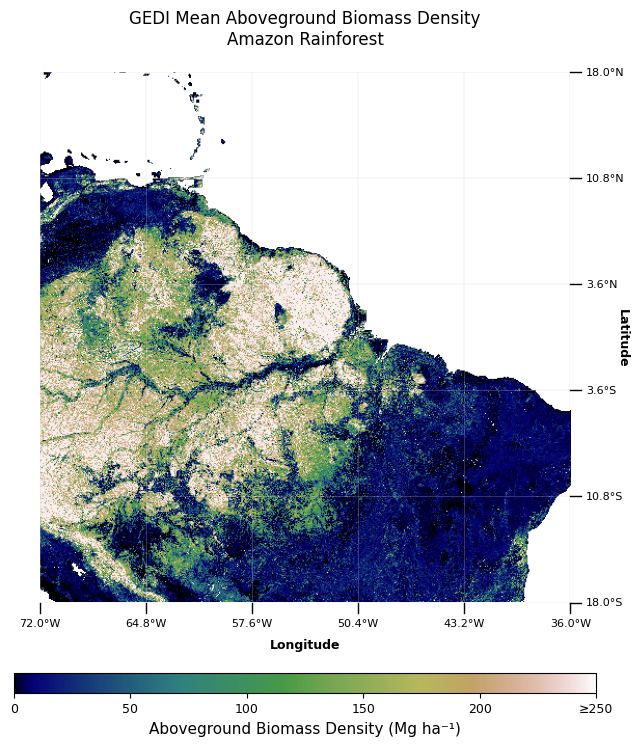

In [178]:
# Amazon rainforest coordinates
lon = -60.0  # West
lat = -3.0   # South
zoom = 3

# Prepare subplot with extra space for coordinate labels
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
# Add extra space for labels
fig.subplots_adjust(left=0.1, right=0.85, top=0.9, bottom=0.2)

# Get tile coordinates
col, row = lonlat_to_gedi_tile(lon, lat, zoom)
bbox = tile_to_bbox(col, row, zoom)
img = fetch_gedi_tile(col, row, zoom, GEDI_DATE)

# Display with grid (default opacity is 0.3, but you can adjust)
display_biomass_tile(ax, img, GEDI_DATE, "Amazon Rainforest", bbox, zoom_level=zoom, grid_opacity=0.3)

# Add colorbar
add_gedi_colorbar(fig, ax, shrink=0.6, pad=0.10)

plt.tight_layout()
plt.show()

## Comparing Biomass Across Regions

We further investigate biomass density across different forest ecosystems to examine regional differences.

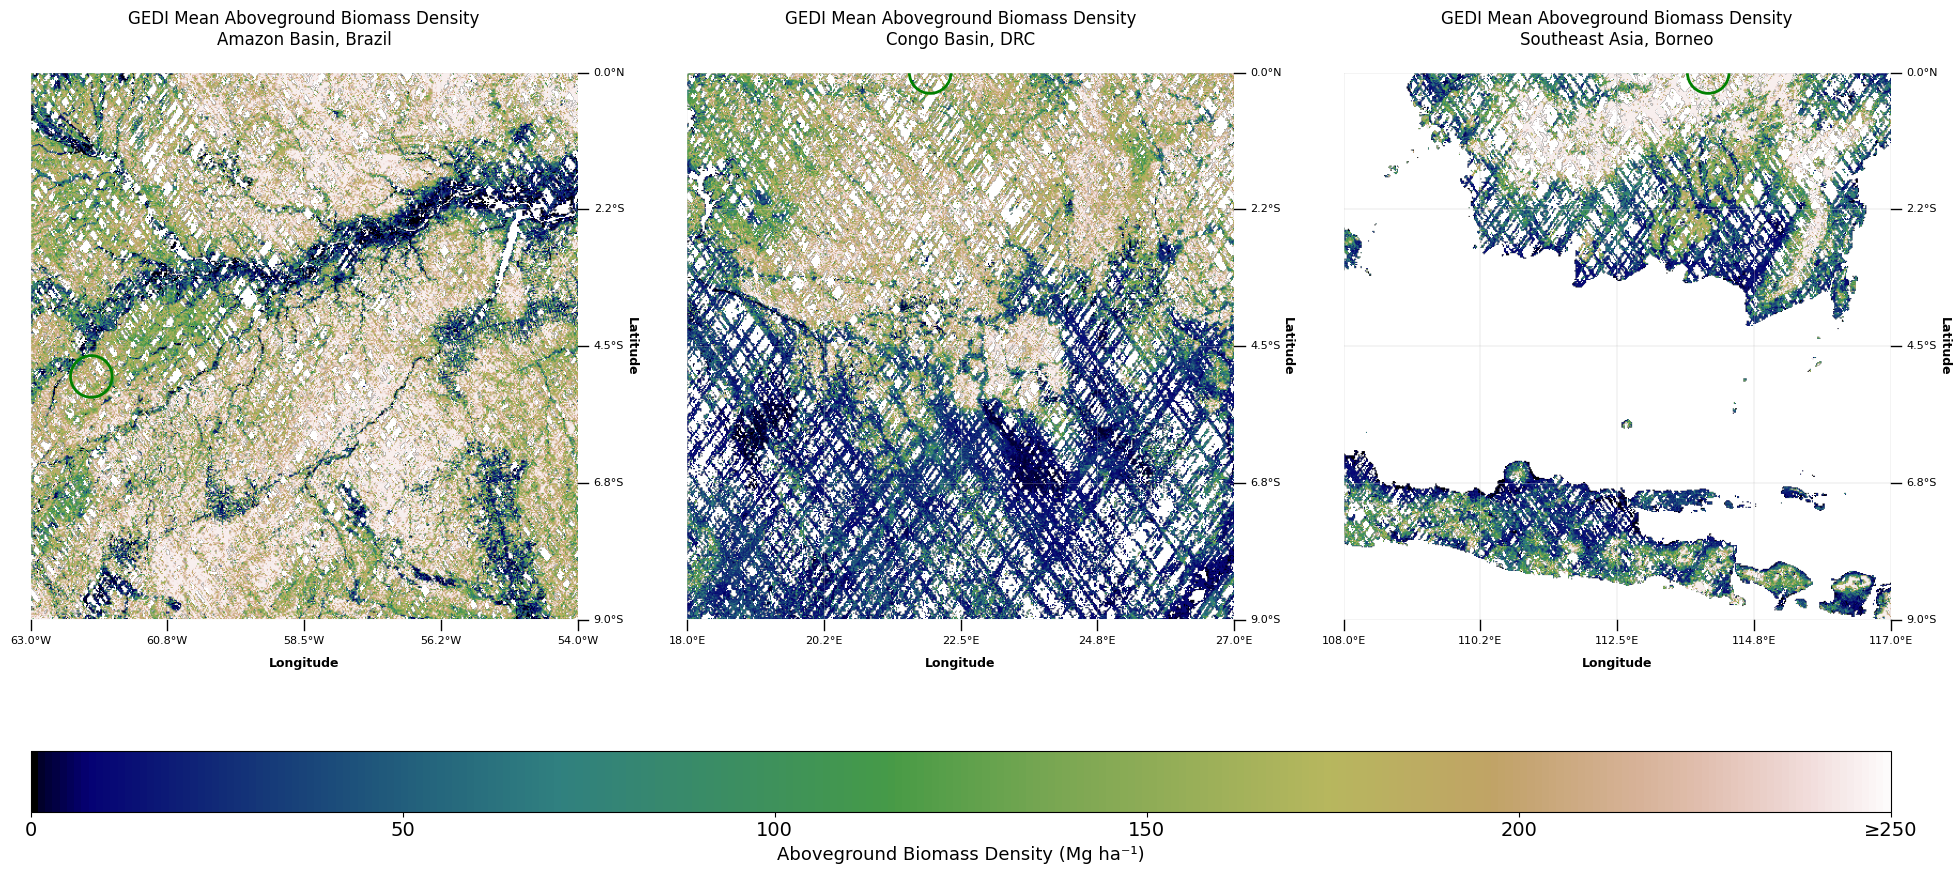

In [182]:
# Forest regions with high biomass density
locations = [
    {"name": "Amazon Basin, Brazil", "lon": -62.0, "lat": -5.0},
    {"name": "Congo Basin, DRC", "lon": 22.0, "lat": 0.0},
    {"name": "Southeast Asia, Borneo", "lon": 114.0, "lat": 0.0}
]

zoom = 5

# Use GridSpec for better control over layout
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(24, 10))
gs = GridSpec(2, 3, figure=fig, height_ratios=[10, 1], hspace=0.3)

# Create axes for the main plots
axes = [fig.add_subplot(gs[0, i]) for i in range(3)]

# Use different grid opacities for demonstration
grid_opacities = [0.2, 0.3, 0.4]  # Light, medium, heavy grid

for ax, location, opacity in zip(axes, locations, grid_opacities):
    lon, lat = location["lon"], location["lat"]
    
    # Get tile coordinates
    col, row = lonlat_to_gedi_tile(lon, lat, zoom)
    bbox = tile_to_bbox(col, row, zoom)
    
    # Fetch and display tile with custom grid opacity
    img = fetch_gedi_tile(col, row, zoom, GEDI_DATE)
    display_biomass_tile(ax, img, GEDI_DATE, location['name'], bbox, zoom_level=zoom, grid_opacity=opacity)
    
    # Add a marker for the specific location
    if img is not None:
        img_width, img_height = img.size
        x_pos = ((lon - bbox[0]) / (bbox[1] - bbox[0])) * img_width
        y_pos = ((bbox[3] - lat) / (bbox[3] - bbox[2])) * img_height
        
        # Add a green circle at the location
        ax.scatter(x_pos, y_pos, facecolors='none', edgecolors='green', s=900, marker='o', linewidths=2)

# Create a separate axis for the colorbar spanning all columns
cbar_ax = fig.add_subplot(gs[1, :])

# Use matplotlib's gist_earth colormap
cmap = plt.cm.gist_earth
norm = plt.Normalize(vmin=0, vmax=250)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Add colorbar to the dedicated axis
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_ticks([0, 50, 100, 150, 200, 250])
cbar.set_ticklabels(['0', '50', '100', '150', '200', '≥250'])
cbar.set_label('Aboveground Biomass Density (Mg ha⁻¹)', fontsize=13)
cbar.ax.tick_params(labelsize=14)

plt.show()

## Interactive Spatial Comparison

This section provides an interactive interface to compare GEDI aboveground biomass density between different high-biomass forest regions around the world. The GEDI L4B data represents a composite mean from April 2019 to March 2023.

Run the cell below and you will be prompted to select 2 regions of your choice and plot them side-by-side at a specific zoom level. You can also select customized coordinates which can be inserted into the cell. 

In [ ]:
# High biomass forest regions around the world
HIGH_BIOMASS_REGIONS = {
    "Amazon Rainforest, Brazil": {
        "lon": -60.0, "lat": -3.0,
        "description": "World's largest tropical rainforest with exceptional biomass density",
        "recommended_zoom": 4
    },
    "Congo Basin, DRC": {
        "lon": 23.0, "lat": -1.0,
        "description": "Second largest tropical rainforest, critical carbon sink",
        "recommended_zoom": 4
    },
    "Borneo Rainforest, Malaysia": {
        "lon": 114.0, "lat": 1.0,
        "description": "Southeast Asian tropical rainforest with high biodiversity",
        "recommended_zoom": 4
    },
    "Sumatra Rainforest, Indonesia": {
        "lon": 102.0, "lat": -1.0,
        "description": "Indonesian tropical rainforest with dense canopy",
        "recommended_zoom": 4
    },
    "Papua New Guinea Rainforest": {
        "lon": 143.0, "lat": -6.0,
        "description": "Third largest tropical rainforest, largely intact",
        "recommended_zoom": 4
    },
    "Pacific Northwest, USA": {
        "lon": -122.5, "lat": 47.0,
        "description": "Temperate rainforest with massive conifers",
        "recommended_zoom": 5
    },
    "Valdivian Rainforest, Chile": {
        "lon": -72.5, "lat": -40.0,
        "description": "South American temperate rainforest",
        "recommended_zoom": 5
    },
    "Western Ghats, India": {
        "lon": 76.5, "lat": 11.0,
        "description": "Biodiversity hotspot with tropical forests",
        "recommended_zoom": 5
    },
    "Queensland Rainforest, Australia": {
        "lon": 145.5, "lat": -16.0,
        "description": "Ancient Gondwana rainforest remnants",
        "recommended_zoom": 5
    },
    "Custom Location": {
        "lon": 0.0, "lat": 0.0,
        "description": "Enter your own coordinates",
        "recommended_zoom": 4
    }
}

# Create widgets for region comparison
region1_dropdown = widgets.Dropdown(
    options=list(HIGH_BIOMASS_REGIONS.keys()),
    value='Amazon Rainforest, Brazil',
    description='Region 1:',
    style={'description_width': 'initial'}
)

region2_dropdown = widgets.Dropdown(
    options=list(HIGH_BIOMASS_REGIONS.keys()),
    value='Congo Basin, DRC',
    description='Region 2:',
    style={'description_width': 'initial'}
)

zoom_dropdown = widgets.Dropdown(
    options=[
        ('Zoom 2 - Continental', 2),
        ('Zoom 3 - Regional', 3),
        ('Zoom 4 - Sub-regional', 4),
        ('Zoom 5 - Local', 5)
    ],
    value=4,
    description='Zoom Level:',
    style={'description_width': 'initial'}
)

# Custom coordinates for Region 1 (hidden by default)
custom_lon1 = widgets.FloatText(value=0.0, description='Longitude 1:', 
                                layout=widgets.Layout(display='none'), style={'description_width': 'initial'})
custom_lat1 = widgets.FloatText(value=0.0, description='Latitude 1:', 
                                layout=widgets.Layout(display='none'), style={'description_width': 'initial'})

# Custom coordinates for Region 2 (hidden by default)
custom_lon2 = widgets.FloatText(value=0.0, description='Longitude 2:', 
                                layout=widgets.Layout(display='none'), style={'description_width': 'initial'})
custom_lat2 = widgets.FloatText(value=0.0, description='Latitude 2:', 
                                layout=widgets.Layout(display='none'), style={'description_width': 'initial'})

# Note about GEDI data
note_text = widgets.HTML(
    value="""
    <div style='background-color: #f0f8ff; padding: 10px; border-radius: 5px; margin: 10px 0;'>
    <b>🌳 High Biomass Forest Regions:</b><br>
    Compare GEDI aboveground biomass density between different forest regions around the world. 
    The data represents the mean biomass density from April 2019 to March 2023. 
    Select two regions from the dropdowns to visualize their biomass patterns side by side.
    </div>
    """
)

def on_region1_change(change):
    """Update zoom and coordinate visibility for region 1."""
    selected_region = change['new']
    region_data = HIGH_BIOMASS_REGIONS[selected_region]
    
    # Update zoom with recommended zoom
    if region1_dropdown.value != 'Custom Location' and region2_dropdown.value != 'Custom Location':
        # Use the minimum zoom level between both regions for consistency
        zoom1 = HIGH_BIOMASS_REGIONS[region1_dropdown.value].get('recommended_zoom', 4)
        zoom2 = HIGH_BIOMASS_REGIONS[region2_dropdown.value].get('recommended_zoom', 4)
        zoom_dropdown.value = min(zoom1, zoom2)
    
    # Show/hide custom coordinates
    if selected_region == 'Custom Location':
        custom_lon1.layout.display = 'block'
        custom_lat1.layout.display = 'block'
    else:
        custom_lon1.layout.display = 'none'
        custom_lat1.layout.display = 'none'

def on_region2_change(change):
    """Update zoom and coordinate visibility for region 2."""
    selected_region = change['new']
    region_data = HIGH_BIOMASS_REGIONS[selected_region]
    
    # Update zoom with recommended zoom
    if region1_dropdown.value != 'Custom Location' and region2_dropdown.value != 'Custom Location':
        # Use the minimum zoom level between both regions for consistency
        zoom1 = HIGH_BIOMASS_REGIONS[region1_dropdown.value].get('recommended_zoom', 4)
        zoom2 = HIGH_BIOMASS_REGIONS[region2_dropdown.value].get('recommended_zoom', 4)
        zoom_dropdown.value = min(zoom1, zoom2)
    
    # Show/hide custom coordinates
    if selected_region == 'Custom Location':
        custom_lon2.layout.display = 'block'
        custom_lat2.layout.display = 'block'
    else:
        custom_lon2.layout.display = 'none'
        custom_lat2.layout.display = 'none'

region1_dropdown.observe(on_region1_change, names='value')
region2_dropdown.observe(on_region2_change, names='value')

# Display widgets
display(widgets.VBox([
    note_text,
    widgets.HBox([region1_dropdown, region2_dropdown, zoom_dropdown]),
    widgets.HBox([custom_lon1, custom_lat1]),
    widgets.HBox([custom_lon2, custom_lat2]),
    widgets.HTML("<p style='font-size: 0.95em; color: #666;'><b>Note:</b> GEDI provides biomass density estimates " +
                 "for forests between 51.6°N and 51.6°S. Areas outside this range or non-forest areas may show no data.</p>"),
    widgets.HTML("<p style='font-size: 0.95em; color: #333;'><b>Instructions:</b> Select two regions to compare, " +
                 "then run the next cell to visualize their biomass density patterns.</p>")
]))

print("✅ Interactive controls ready. Run the next cell to create the comparison visualization.")

✅ Interactive controls ready. Run the next cell to create the comparison visualization.


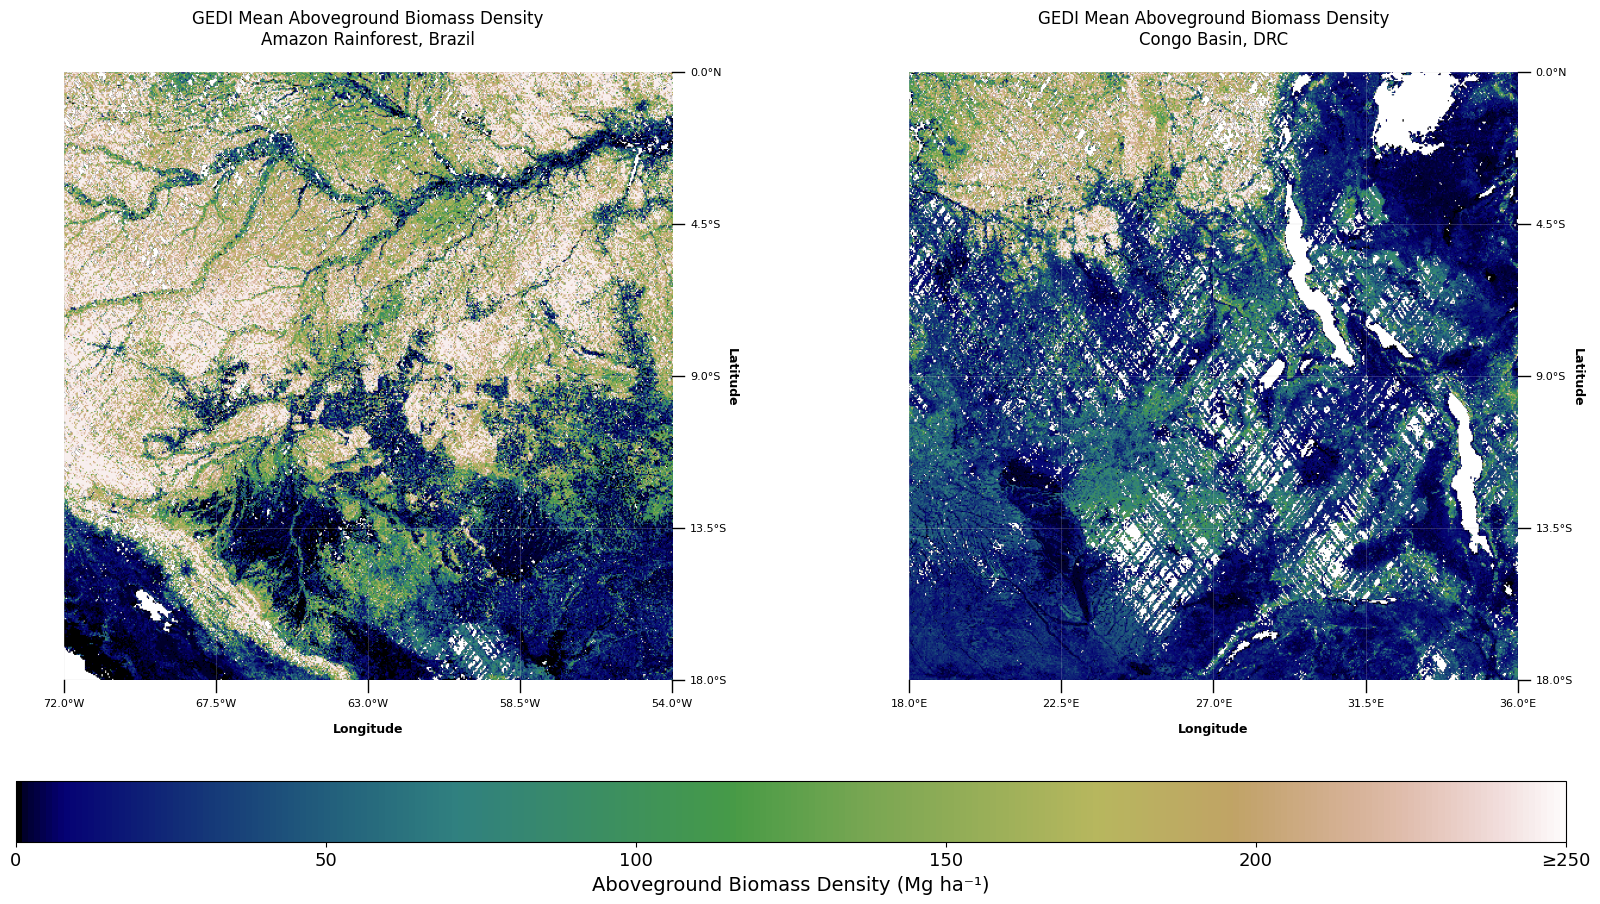

In [181]:
# Create visualization based on selected regions
region1 = region1_dropdown.value
region2 = region2_dropdown.value
zoom = zoom_dropdown.value

# Get coordinates for both regions
if region1 == 'Custom Location':
    lon1, lat1 = custom_lon1.value, custom_lat1.value
    desc1 = "Custom Location"
else:
    point1 = HIGH_BIOMASS_REGIONS[region1]
    lon1, lat1 = point1['lon'], point1['lat']
    desc1 = point1['description']

if region2 == 'Custom Location':
    lon2, lat2 = custom_lon2.value, custom_lat2.value
    desc2 = "Custom Location"
else:
    point2 = HIGH_BIOMASS_REGIONS[region2]
    lon2, lat2 = point2['lon'], point2['lat']
    desc2 = point2['description']



fig = plt.figure(figsize=(20, 10))
gs = GridSpec(2, 2, figure=fig, height_ratios=[10, 1], hspace=0.3)

# Create axes for the two plots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Process both regions
regions = [(ax1, region1, lon1, lat1), (ax2, region2, lon2, lat2)]

for ax, region_name, lon, lat in regions:
    # Get tile coordinates
    col, row = lonlat_to_gedi_tile(lon, lat, zoom)
    bbox = tile_to_bbox(col, row, zoom)
    
    # Fetch tile using the standard GEDI date
    img = fetch_gedi_tile(col, row, zoom, GEDI_DATE)
    
    # Display with region name
    display_biomass_tile(ax, img, GEDI_DATE, region_name, 
                       bbox, zoom_level=zoom, grid_opacity=0.25)

# Create a colorbar axis spanning both columns
cbar_ax = fig.add_subplot(gs[1, :])

# Add colorbar
cmap = plt.cm.gist_earth
norm = plt.Normalize(vmin=0, vmax=250)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_ticks([0, 50, 100, 150, 200, 250])
cbar.set_ticklabels(['0', '50', '100', '150', '200', '≥250'])
cbar.set_label('Aboveground Biomass Density (Mg ha⁻¹)', fontsize=14)
cbar.ax.tick_params(labelsize=13)

plt.show()


## Summary

In this notebook we have successfully completed the following steps for the GEDI Aboveground Biomass Density dataset:

1. Installed and imported the necessary libraries
2. Fetched the dataset metadata from the STAC API using the collection name
3. Defined the tile matrix parameters for global biomass visualization  
4. Retrieved and visualized biomass density tiles for the Amazon rainforest
5. Compared biomass patterns across three major forest regions (Amazon, Congo, Borneo)
6. Created an interactive interface to compare biomass between any two high-biomass forest regions
7. Demonstrated the spatial distribution of forest biomass for carbon monitoring applications

If you have any questions regarding this user notebook, please contact us using the [feedback form](https://docs.google.com/forms/d/e/1FAIpQLSeVWCrnca08Gt_qoWYjTo6gnj1BEGL4NCUC9VEiQnXA02gzVQ/viewform).